In [ ]:
# install required packages
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install kagglehub

In [1]:
# In a Jupyter notebook cell:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Country-data.csv"

df = kagglehub. dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path,
)

print("First 5 records:")
print(df.head())

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 9.01k/9.01k [00:00<00:00, 2.76MB/s]

First 5 records:


               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [2]:
print(df.shape)
print(df.columns)

(167, 10)
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB
None


In [4]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
print(df.duplicated().sum())

0


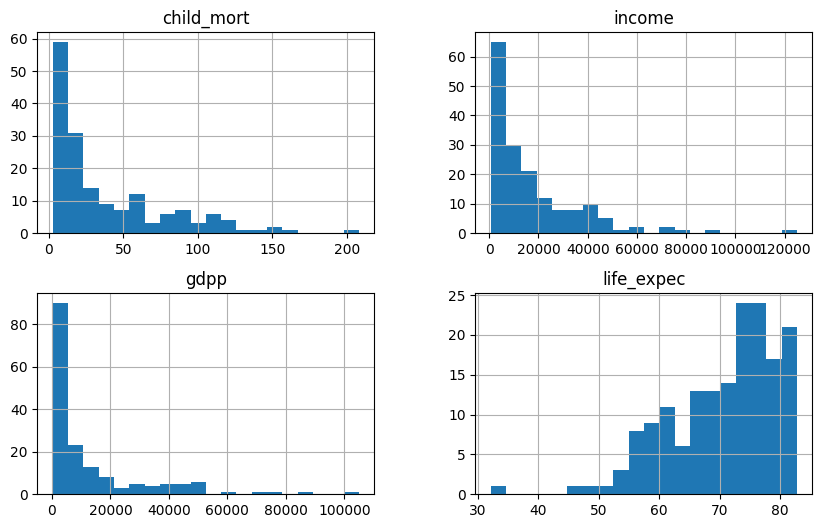

In [7]:
# Core EDA(distribution analysis)
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['child_mort', 'income', 'gdpp', 'life_expec']

df[cols].hist(bins=20, figsize=(10,6))
plt.show()

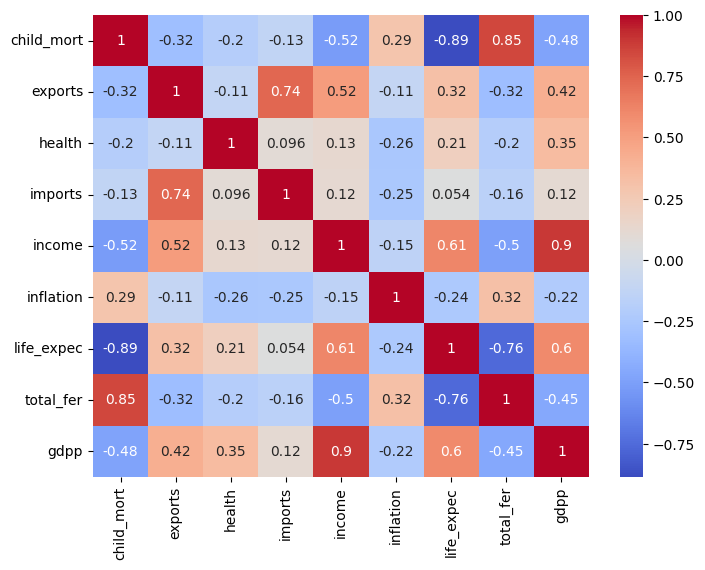

In [8]:
# Correlation analysis
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

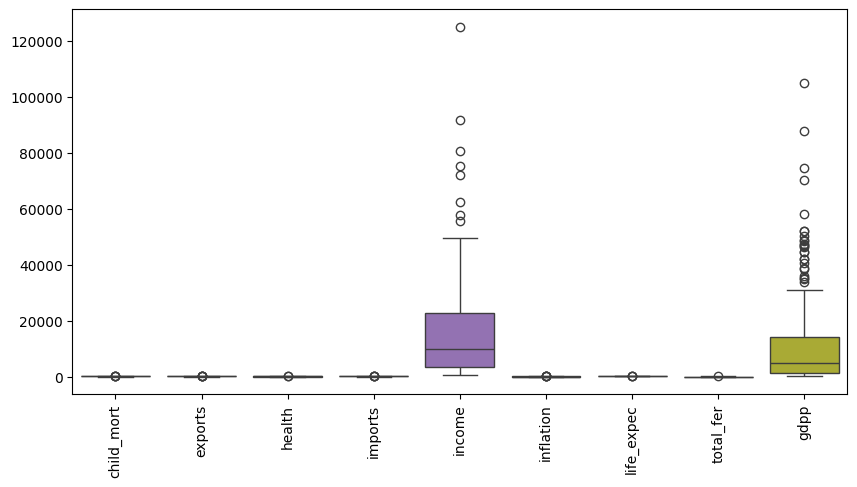

In [9]:
# outlier detection
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop('country', axis=1))
plt.xticks(rotation=90)
plt.show()

In [10]:
# Richiest country:
df.sort_values('gdpp', ascending=False).head(10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
114,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800
145,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
123,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,81.5,1.98,52100
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
110,Netherlands,4.5,72.0,11.90,63.6,45500,0.848,80.7,1.79,50300
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700
159,United States,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400


In [11]:
# Poorest countries:
df.sort_values('gdpp', ascending=True).head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
26,Burundi,93.6,8.92,11.60,39.2,764,12.30,57.7,6.26,231
88,Liberia,89.3,19.10,11.80,92.6,700,5.47,60.8,5.02,327
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.80,57.5,6.54,334
112,Niger,123.0,22.20,5.16,49.1,814,2.55,58.8,7.49,348
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.20,55.0,5.20,399
93,Madagascar,62.2,25.00,3.77,43.0,1390,8.79,60.8,4.60,413
106,Mozambique,101.0,31.50,5.21,46.2,918,7.64,54.5,5.56,419
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.01,47.5,5.21,446
94,Malawi,90.5,22.80,6.59,34.9,1030,12.10,53.1,5.31,459
50,Eritrea,55.2,4.79,2.66,23.3,1420,11.60,61.7,4.61,482


In [12]:
# Worst child mortality
df.sort_values('child_mort', ascending=False).head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.20,55.0,5.20,399
32,Chad,150.0,36.8,4.53,43.5,1930,6.39,56.5,6.59,897
31,Central African Republic,149.0,11.8,3.98,26.5,888,2.01,47.5,5.21,446
97,Mali,137.0,22.8,4.98,35.1,1870,4.37,59.5,6.55,708
113,Nigeria,130.0,25.3,5.07,17.4,5150,104.00,60.5,5.84,2330
112,Niger,123.0,22.2,5.16,49.1,814,2.55,58.8,7.49,348
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
25,Burkina Faso,116.0,19.2,6.74,29.6,1430,6.81,57.9,5.87,575
37,"Congo, Dem. Rep.",116.0,41.1,7.91,49.6,609,20.80,57.5,6.54,334


📊 EDA Summary — Country Clustering
📦 Dataset Overview
Contains socio-economic and health indicators of countries
No missing values
Only country is categorical, rest are numerical
📈 Distributions
income & gdpp → highly right-skewed (big inequality)
child_mort → skewed with extreme values
life_expec → more normally distributed
🔗 Correlation Insights
Strong positive:
income ↔ gdpp (0.90)
income ↔ life_expec (0.61)
Strong negative:
child_mort ↔ life_expec (-0.89)
child_mort ↔ income (-0.52)

👉 Wealth → better health & longer life

📦 Outliers
Significant outliers in income and gdpp
Represent highly developed countries
Kept as they are meaningful
🧠 Key Insight

Clear separation exists between developed and underdeveloped countries, making the dataset ideal for clustering.

In [13]:
# feature scaling (prepare feature matrix)

X = df.drop('country', axis=1)
countries = df['country']

In [14]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python314

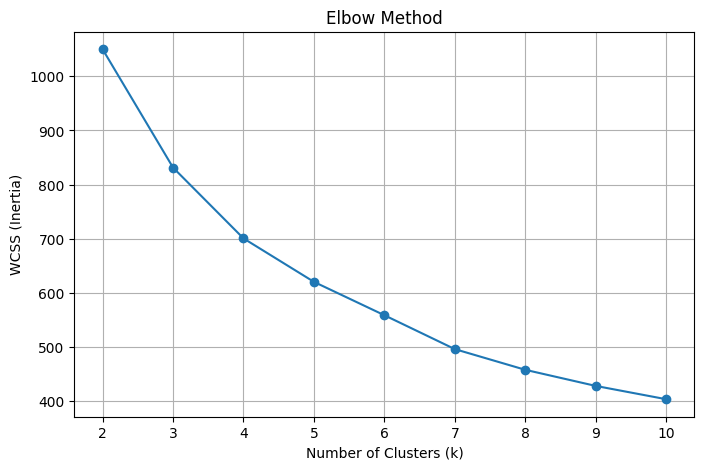

In [16]:
# Lets start clustering(k means)
# STEP 1 — Find optimal number of clusters (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [17]:
from sklearn.cluster import KMeans

best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [18]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("="*50)
print("Silhouette Score :", round(score, 4))
print("="*50)

if score > 0.5:
    print("Good cluster separation.")
elif score > 0.25:
    print("Moderate cluster separation.")
else:
    print("Weak cluster separation.")

Silhouette Score : 0.2833
Moderate cluster separation.


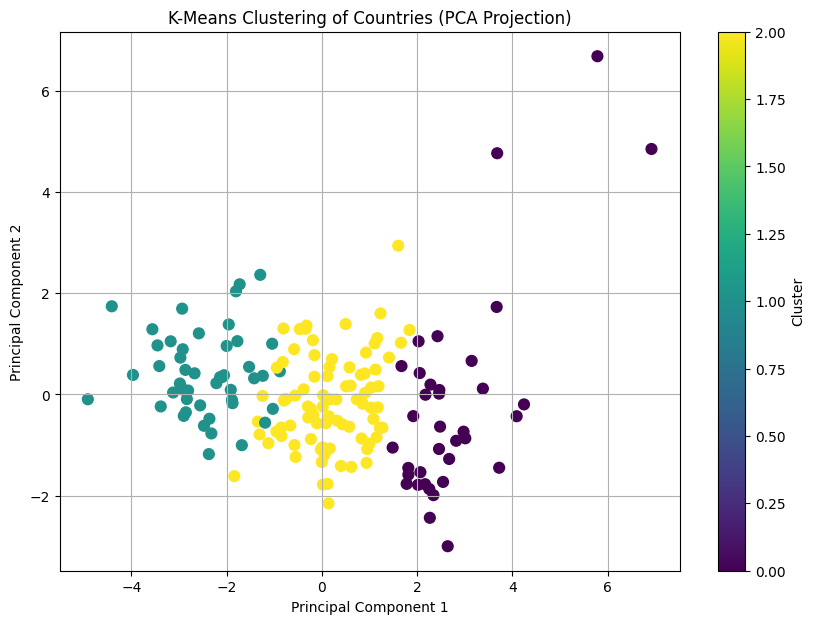

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis',
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Countries (PCA Projection)")

plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

Observation 1

Countries with high child mortality and low life expectancy are grouped together, indicating regions with poor healthcare facilities and lower socio-economic development.

Observation 2

Countries having high GDP per capita and high income levels form a separate cluster representing developed economies with better living standards.

Observation 3

Countries with moderate economic indicators lie between developed and underdeveloped nations, representing emerging economies with improving infrastructure.

Observation 4

The clustering process effectively separates countries based on health and economic indicators, demonstrating meaningful patterns in the dataset.

Observation 5

The PCA visualization confirms that the clusters are reasonably separated, showing that K-Means successfully identified distinct socio-economic groups.

In [20]:
df['Cluster'] = clusters
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [21]:
df.groupby('Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [22]:
# DATA PREP FOR SUPERVISED LEARNING

df['target'] = df['Cluster'].apply(lambda x: 1 if x == 1 else 0)

In [23]:
X = df.drop(['country', 'Cluster', 'target'], axis=1)
y = df['target']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# CLASSIFICATION MODELS
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [26]:
# XB BOOST

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [27]:
from sklearn.metrics import classification_report

print("Random Forest:")
print(classification_report(y_test, rf_pred))

print("XGBoost:")
print(classification_report(y_test, xgb_pred))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        10

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        10

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [28]:
# Ensembel learning

from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
ensemble_pred = ensemble.predict(X_test)

print(classification_report(y_test, ensemble_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        10

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [29]:
# DBSCAN(Anamoly detection)

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [30]:
# Identify Outliers
outliers = df[df['DBSCAN_Cluster'] == -1]
outliers[['country', 'child_mort', 'income', 'gdpp']]

,country,child_mort,income,gdpp
3,Angola,119.0,5900,3530
23,Brunei,10.5,80600,35300
31,Central African Republic,149.0,888,446
37,"Congo, Dem. Rep.",116.0,609,334
38,"Congo, Rep.",63.9,5190,2740
49,Equatorial Guinea,111.0,33700,17100
55,Gabon,63.7,15400,8750
66,Haiti,208.0,1500,662
72,Iraq,36.9,12700,4500
73,Ireland,4.2,45700,48700


In [31]:
priority_countries = df[df['target'] == 1].sort_values(
    by=['child_mort', 'income', 'gdpp'],
    ascending=[False, True, True]
)

priority_countries.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,target,DBSCAN_Cluster
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662,1,1,-1
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.20,55.0,5.20,399,1,1,-1
32,Chad,150.0,36.8,4.53,43.5,1930,6.39,56.5,6.59,897,1,1,0
31,Central African Republic,149.0,11.8,3.98,26.5,888,2.01,47.5,5.21,446,1,1,-1
97,Mali,137.0,22.8,4.98,35.1,1870,4.37,59.5,6.55,708,1,1,0
113,Nigeria,130.0,25.3,5.07,17.4,5150,104.00,60.5,5.84,2330,1,1,-1
112,Niger,123.0,22.2,5.16,49.1,814,2.55,58.8,7.49,348,1,1,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,1,-1
37,"Congo, Dem. Rep.",116.0,41.1,7.91,49.6,609,20.80,57.5,6.54,334,1,1,-1
25,Burkina Faso,116.0,19.2,6.74,29.6,1430,6.81,57.9,5.87,575,1,1,0
